In [7]:
import torch
from ultralytics import YOLO
from PIL import Image
import numpy as np

In [2]:
model = YOLO("best.pt")

In [ ]:
test_img = Image.open("../data/test_img1.jpg")
test_img = test_img.resize(size=(640, 640))
tensor_test_img = torch.tensor(np.array(test_img))
tensor_test_img.shape

torch.Size([640, 640, 3])

In [12]:
results = model.predict(source="../data/test_img1.jpg", verbose=False)
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'WBC', 1: 'RBC', 2: 'Platelet'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255

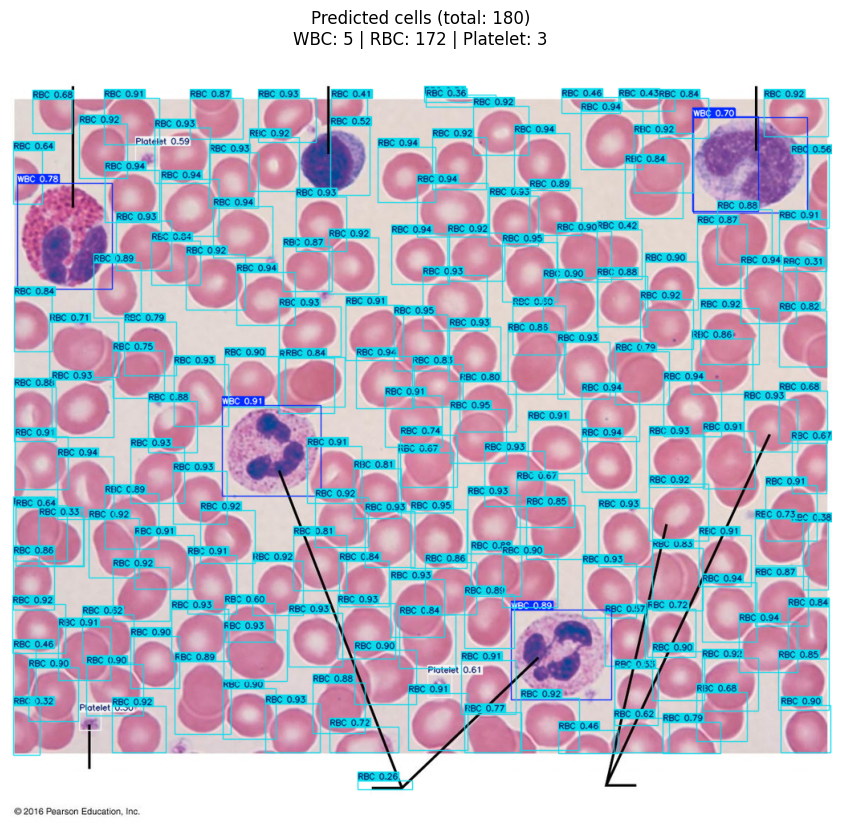

Total detections: 180
WBC: 5 | RBC: 172 | Platelet: 3


In [15]:
from collections import Counter
import matplotlib.pyplot as plt

result = results[0]
class_counts = Counter(result.boxes.cls.cpu().numpy().astype(int))
count_summary = " | ".join(
    f"{name}: {class_counts.get(class_id, 0)}"
    for class_id, name in result.names.items()
)

annotated_image = result.plot(labels=True, line_width=1, font_size=1.2, conf=True)
plt.figure(figsize=(14, 10))
plt.imshow(annotated_image[..., ::-1])
plt.axis("off")
plt.title(f"Predicted cells (total: {sum(class_counts.values())})\n{count_summary}")
plt.show()

print(f"Total detections: {sum(class_counts.values())}")
print(count_summary)